# Benchmarking on pseudo-ST data

## 1. Import CellRefiner and packages

In [2]:
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import cellrefiner as cr

## 2. Load Data

The MERFISH dataset is available via the squidpy package.

In [3]:
ad = sq.datasets.merfish()
ad = ad[ad.obs.Bregma == -9]

Generate sc data

In [4]:
ad_sc=AnnData(ad.X)
ad_sc.obs_names=[f'Cell_{i}' for i in range(ad_sc.shape[0])]
ad_sc.var_names=ad.var_names
ad_sc.obsm['spatial']=ad.obsm['spatial']
ad_sc.obs['Cell_type']=pd.Categorical(ad.obs['Cell_class'])

Generate pseudo st data

In [5]:
from scipy.spatial import KDTree
A=ad.obsm['spatial']
n1=32
n2=32
R=80/5000
max_neighbors=5
min_coords = np.min(A, axis=0)
max_coords = np.max(A, axis=0)
    
# Create evenly spaced grid
x = np.linspace(min_coords[0], max_coords[0], n1)
y = np.linspace(min_coords[1], max_coords[1], n2)
    
# Create meshgrid
X, Y = np.meshgrid(x, y)
    
# Reshape into a list of points
grid_points = np.vstack([X.ravel(), Y.ravel()]).T
    
# Build KD-Tree for efficient nearest neighbor search
tree = KDTree(A)
    
# Find neighbors within distance R for each grid point
neighbors_list = []
distances_list = []
    
for point in grid_points:
    # Query the KD-Tree for neighbors within distance R
    distances, indices = tree.query(point, k=len(A), distance_upper_bound=R)
        
    # Filter out invalid indices (indicated by index == len(A))
    valid_mask = indices < len(A)
    valid_indices = indices[valid_mask]
    valid_distances = distances[valid_mask]
        
    # Take at most max_neighbors
    if len(valid_indices) > max_neighbors:
        # Sort by distance and take the closest max_neighbors
        sorted_idx = np.argsort(valid_distances)[:max_neighbors]
        valid_indices = valid_indices[sorted_idx]
        
    neighbors_list.append(valid_indices)
if type(ad.X)=='scipy.sparse._csr.csr_matrix':
    M=ad.X.toarray()
else:
    M=ad.X
        
# Initialize the new matrix with zeros
M1 = np.zeros((len(neighbors_list), M.shape[1]))
    
# For each grid point
for i, neighbor_indices in enumerate(neighbors_list):
    if len(neighbor_indices) > 0:  # Check if there are any neighbors
        # Sum the rows of M indexed by the neighbors
        M1[i] = np.sum(M[neighbor_indices], axis=0)

In [6]:
ad_st=AnnData(M1)
ad_st.obsm['spatial']=grid_points
ad_st.obs_names=[f'Spot_{i}' for i in range(ad_st.shape[0])]
ad_st.var_names=ad.var_names

Preprocess

In [7]:
sc.pp.filter_cells(ad_sc,min_genes=3)
sc.pp.filter_genes(ad_sc,min_cells=3)
sc.pp.normalize_total(ad_sc)
sc.pp.log1p(ad_sc)
sc.pp.highly_variable_genes(ad_sc)
ad_sc = ad_sc[:,ad_sc.var['highly_variable']]

## 3. Run cellrefiner cell to spot mapping and spatial refinement 

Load the ligand-receptor database sourced from CellChat

In [9]:
db_lr = cr.pp.ligand_receptor_database()
adata_cr = cr.pp.spatial_mapping(ad_st,ad_sc,db_lr,scale=.016,cluster_key_sc = 'Cell_type')

/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


CuPy not available


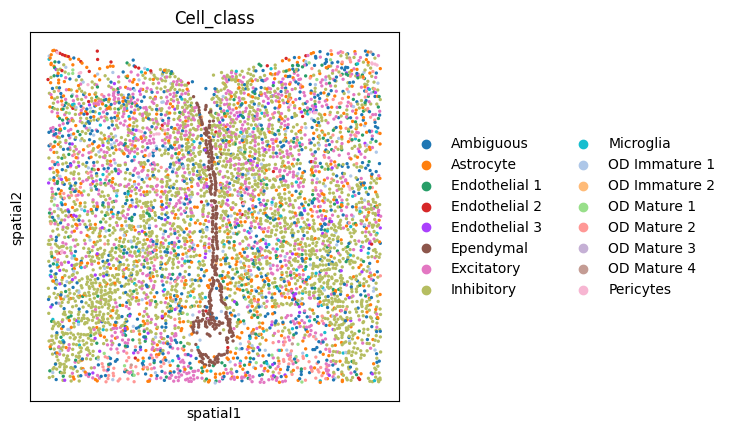

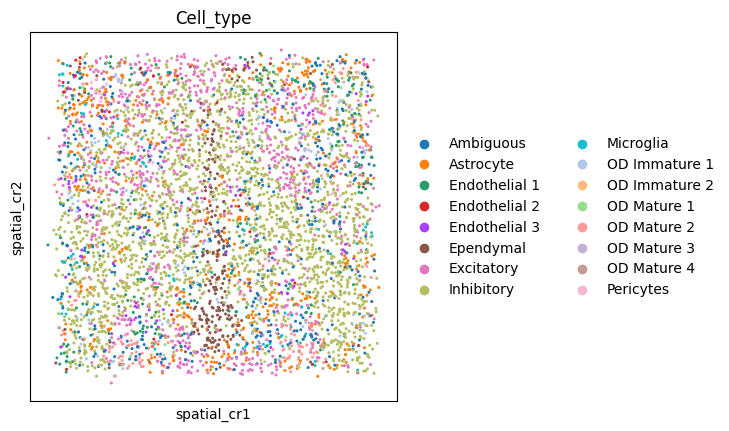

In [10]:
sc.pl.spatial(ad,color = 'Cell_class',spot_size = 0.01)
sc.pl.spatial(adata_cr,color = 'Cell_type',spot_size = 0.01,basis='spatial_cr')